In [2]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import csv
import time
import os
import glob
import json
import numpy as np
import tensorflow as tf
import sys

In [3]:
import sys
fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)


old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

In [4]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
run_models non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache
old_cellCnn.model_grid non trovato nella cache


In [35]:

import os
import csv
import pandas as pd
n_sub_tuning_path = f'{save_path}old/n_sub_tuning/'
if n_sub_tuning_path not in sys.path:
    sys.path.append(n_sub_tuning_path)

# find saved nsub tuning results
n_sub_models = retrieve_nsub_models_names(n_sub_tuning_path)
print(n_sub_models)
mod = n_sub_models[-1] # model name to check

config_df = pd.read_csv(f'{n_sub_tuning_path}{mod}/nsub_tuning_conf.csv')

seed =  config_df.loc[0, 'seed']
n_sub = config_df.loc[0, 'n_sub']
n_cells = config_df.loc[0, 'n_cells']
blast_perc = str_to_list(config_df.loc[0, 'blast_perc'])
nfilter = str_to_list(config_df.loc[0, 'nfilter'])
maxpool_p = str_to_list(config_df.loc[0, 'maxpool_p'])
learning_r = str_to_list(config_df.loc[0, 'learning_r'])
blocks = config_df.loc[0, 'blocks']
step = config_df.loc[0, 'step']
grid = config_df.loc[0, 'grid']
labels = config_df.loc[0, 'labels']

print(seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(nfilter)
print(maxpool_p)
print(learning_r)
print(blocks)
print(step)
print(grid)
print(labels)



['model_1', 'model_14_11_0.0001%_1', 'model_14_11_0.001%_1', 'model_2']
105619
5
100000
[0.0001, 0.0005, 0.001, 0.005, 0.01]
[3.0, 5.0, 7.0, 9.0]
[0.01, 1.0, 5.0, 20.0, 100.0]
[0.001]
10
20
False
False


In [8]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\Enrico Didoli\0.Master_Thesis

In [24]:

def flatten(nested):
    """Returns a list from a nested list"""
    if nested is None: # concludes the recursive search
        return []
    if not isinstance(nested, (list, tuple)):
        return [nested]
        
    nested = list(nested)
    result = []
    for item in nested:
        result.extend(flatten(item)) # recusively explore the nested lists
    return result

def retrieve_labels(datasets_extracted, remove = False, flat = False):
    """Extracts labels from a nested list of datasets
    Inputs: - datasets_extracted: colection of datatasets. Each element is a list itself. 
                                Outer list: patients. Inner list: time points provided by the patient 
            - remove: bool() -> If True, removes the labels from each cell
            - flat: bool() -> converts to a single list of dataframes (list of files)"""
    per_patient_datasets = []
    per_patient_y = []

    for patient in datasets_extracted:
        patient_datasets = []
        patient_ys = []
        for dataset in patient:
            if (dataset['IsBlast'] == 1).sum() > 0:
                patient_ys.append(1)
            else:
                patient_ys.append(0)
                
            if remove:
                dataset = dataset.drop(columns = ['IsBlast'])

            patient_datasets.append(dataset)


        per_patient_datasets.append(patient_datasets)
        per_patient_y.append(patient_ys)


    if flat:
        per_patient_datasets = flatten(per_patient_datasets)
        per_patient_y = flatten(per_patient_y)
        
    return per_patient_datasets, per_patient_y 
    
def remove_labels(datasets):
    """ Remove IsBlast labels from every cell in the dataset"""
    no_label_datasets = []
    for ds in datasets:
        dataset = ds.drop(columns = ['IsBlast'])
        
        no_label_datasets.append(dataset)
    #print(len(no_label_datasets))
    return no_label_datasets
    
def grid_or_rand_model(grid):
    """Returns the model according to the hyperparameter selection"""
    if grid:
        remove_from_cache(['old_cellCnn.model_grid']) # remove model from cache to ensure the correct importing
        from old_cellCnn.model_grid import CellCnn    # import model 
    else:
        remove_from_cache(['old_cellCnn.model'])
        from old_cellCnn.model import CellCnn
    return CellCnn

def train_val_finalizing(train_datasets, val_datasets, grid, labels):
    """Elaborate Training and validation according to the hyper selection and selected subsampling method
        Inputs: - grid: bool() -> if True, grid search is performed and labels is set to False.  
                - labels: bool() -> if True, the subsampling is performed to maintain the distributions of the train\val datasets.
    """
    if grid:
        train = remove_labels(train_datasets)
        val = remove_labels(val_datasets)
        print(f'_abels from Train and Validations Sets have been REMOVED.\nGrid Search Ready!')
    else:
        if not labels: # if random search but we don't want use labels
            train = remove_labels(train_datasets)
            val = remove_labels(val_datasets)
            print(f'labels from Train and Validations Sets have been REMOVED.\nRandom Search Ready!')
            
        else:
            train = train_datasets
            val = val_datasets
            print(f'Labels from Train and Validations Sets have been PRESERVED.\nRandom Search Ready!')
            
    return train, val 

def nsub_to_evaluate(blocks, step):
    """ Returns the list of nsub values we want to evaluate"""
    nsub_list = list(range(step, step*(blocks +1), step))
    return nsub_list

def generate_seeds(n = 10, seed = None):
    """ Generate seed list """
    if seed is None:
        print('Warning: random generation. No Reproducibility!')
        print('Reproducibility -> add "seed:int()" parameter!')
    else:
        np.random.seed(seed)
    return np.random.choice(10**6, n)

def find_best_nsubs(f1_step_1, nsub_list, n = 5, indices = False):
    """ Returns the n nsub values that performed best. If multiple values have the highest f1_score, higher values are prefered"""
    
    idx = np.argsort(f1_step_1) # fi_step_1 elements' indices ordered in acscending order (the last element is the index of the best element in f1_step_1)
    unique_values = np.sort(list(set(f1_step_1.copy()))) #sort function returns the sorted uniques values of a list

    f1_5_best, best_5_idx = [], []
    for value in unique_values[::-1]:
        counter = len(f1_step_1) - 1
        
        for element in f1_step_1[::-1]: 
            
            if element == value:
                f1_5_best.append(element)
                best_5_idx.append(counter)
                
            if len(best_5_idx) == n:
                print(f'5 best f1_score values: {f1_5_best} at indexes: {best_5_idx}')

                if indices: 
                    return np.sort(np.array(nsub_list)[best_5_idx]), best_5_idx
                else:
                    return np.sort(np.array(nsub_list)[best_5_idx])
                
            counter -= 1
    return


def retrieve_nsub_models_names(n_sub_tuning_path):
    """ Retrieve nsub folders names """

    def extract_num(folder_name):
        if 'model_' in folder_name:
            return folder_name
    # get folder_names
    n_sub_cartelle = [
        nome for nome in os.listdir(n_sub_tuning_path)
        if os.path.isdir(os.path.join(n_sub_tuning_path , nome))]
    
    n_sub_models = [
        extract_num(model) for model in n_sub_cartelle 
        if extract_num(model) is not None]
    
    return n_sub_models
    
def load_nsub_tuning_steps(n_sub_tuning_path, mod):

    """step 1"""
    with open(f'{n_sub_tuning_path}{mod}/step_1_acc.json', "r", encoding="utf-8") as f:
            n_sub_step1_acc = json.load(f)
    with open(f'{n_sub_tuning_path}{mod}/step_1_f1.json', "r", encoding="utf-8") as f:
            n_sub_step1_f1 = json.load(f)
    with open(f'{n_sub_tuning_path}{mod}/step_1_x_axis.json', "r", encoding="utf-8") as f:
            n_sub_step1_x_axis = json.load(f)

    """step 2"""
    with open(f'{n_sub_tuning_path}{mod}/step_2_acc.json', "r", encoding="utf-8") as f:
            n_sub_step2_acc = json.load(f)
    with open(f'{n_sub_tuning_path}{mod}/step_2_f1.json', "r", encoding="utf-8") as f:
            n_sub_step2_f1 = json.load(f)
    with open(f'{n_sub_tuning_path}{mod}/step_2_x_axis.json', "r", encoding="utf-8") as f:
            n_sub_step2_x_axis = json.load(f)

    return n_sub_step1_acc, n_sub_step1_f1, n_sub_step1_x_axis, n_sub_step2_acc, n_sub_step2_f1, n_sub_step2_x_axis

def get_secondary_axis(best_5_values, n_sub_step1_x_axis):
    """ creates the labels for the secondary axis in the Step 1 nsub plot """
    secax = []
    for element in n_sub_step1_x_axis: # for nsub_value
        if element in np.sort(best_5_values): # in the best 5
            secax.append(element)
        else:
            secax.append('')
    return secax


def plot_nsub_step_1(n_sub_step1_acc, n_sub_step1_f1, n_sub_step1_x_axis): 
    """ Plots first step of the nsub tuning process """
    best_5_values, best_5_idx = find_best_nsubs(n_sub_step1_f1, n_sub_step1_x_axis, indices = True) # retrieve the best 5 values
    #secax = get_secondary_axis(best_5_values, n_sub_step1_x_axis) # define secondary axes
    secax_best = [str(value) for value in best_5_values]

    max_fig_length = min(int(len(n_sub_step1_x_axis)/1.5), 10)
    fig, ax = plt.subplots(figsize = [max_fig_length, 5])
    #ax.set_xticks(n_sub_step1_x_axis)
    ax.plot(n_sub_step1_x_axis, n_sub_step1_acc, marker='o', label='Accuracy')
    ax.plot(n_sub_step1_x_axis, n_sub_step1_f1, marker='o', label='F1-score')
    
    # --- Twin axis for top labels (only at best points) ---
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(best_5_values)          # ← Only 5 ticks!
    ax2.set_xticklabels(best_5_values,  rotation = 90) # ← Exactly 5 labels
    ax2.set_xlabel("Secondary Value (e.g., Effective Samples)")  # optional label
    
    
    for x, y in zip(np.array(n_sub_step1_x_axis)[best_5_idx], np.array(n_sub_step1_f1)[best_5_idx]): #f1_scores
        ax.text(x, y, f"{y:.2f}", ha='center', va='bottom')

    ax.legend(loc='upper left')
    #ax.grid(True) 
    plt.ylim(0,1)
    plt.title('Positive Class')
    plt.xlabel("Number of Subsets") 
    plt.ylabel("Scores") 
    plt.show()

def plot_nsub_step_2(n_sub_step2_acc, n_sub_step2_f1, n_sub_step2_x_axis):
    """ Plots second step of the nsub tuning process """
    # Calculate Mean and Standard Deviation (Std)
    acc_5_means = [np.mean(acc) for acc in n_sub_step2_acc]
    f1_5_means = [np.mean(f1) for f1 in n_sub_step2_f1]
    acc_5_stds = [np.std(acc) for acc in n_sub_step2_acc]
    f1_5_stds = [np.std(f1) for f1 in n_sub_step2_f1]
    
    max_idx = f1_5_means.index(np.max(f1_5_means))
    
    
    # Plot Accuracy Mean
    plt.plot(n_sub_step2_x_axis, acc_5_means, marker='o', label='Accuracy (Mean)', color='C0')
    # Plot Accuracy Std as a shaded region
    acc_upper = np.array(acc_5_means) + np.array(acc_5_stds)
    acc_lower = np.array(acc_5_means) - np.array(acc_5_stds)
    plt.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')
    
    # Plot F1-score Mean
    plt.plot(n_sub_step2_x_axis, f1_5_means, marker='o', label='F1-score (Mean)', color='C1')
    # Plot F1-score Std as a shaded region
    f1_upper = np.array(f1_5_means) + np.array(f1_5_stds)
    f1_lower = np.array(f1_5_means) - np.array(f1_5_stds)
    plt.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')

    y = f1_5_means[max_idx]
    plt.text(n_sub_step2_x_axis[max_idx], y, f"{y:.2f}", ha='center', va='bottom')
    
    plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
    plt.ylim(0,1)
    plt.title('Positive Class: Performance Mean and Standard Deviation')
    plt.xlabel("Number of Subsets")
    plt.ylabel("Scores")
    plt.legend()
    plt.show()

def str_to_list(b):
    value = ''
    new_b = []
    for element in b:
        if element.isdigit() or element == '.':
            value += element
        elif element in [',', ']']:
            new_b.append(float(value))
            value = ''
    return new_b

In [30]:
seed = 105619 # set the seed

# splits patients in categoties
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

# split patients indices in train, val and test
train_donors_idx, val_donors_idx, test_donors_idx = dataset_elaboration(multiple_donations, ALL_DATASETS, healthy_donors, blast_donors,
                        mixed_donors, seed = seed)

print(train_donors_idx, val_donors_idx, test_donors_idx)

# extract files from patients indices
train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
test_datasets_extracted = donation_extraction(test_donors_idx, multiple_donations, ALL_DATASETS)


{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
Precess starts. Dividing donors...
healthy_donors_idx, blast_donors_idx, mixed_donors_idx: [0, 2, 1], [0, 4, 2, 1, 3],[4, 0, 2, 1, 3]
Seting Train, Validation and Test idx...
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']


In [36]:
print(seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(nfilter)
print(maxpool_p)
print(learning_r)
print(blocks)
print(step)
print(grid)
print(labels)

'''
seed = 105619
n_sub = 3
n_cells = 100000
blast_perc = [0.001, 0.005, 0.01]
nfilter = [3, 5, 7, 9]
best_sub = 200
maxpool_p = [0.01, 1.0, 5.0, 20.0, 100.0]
learning_r = [0.001]
grid = False
labels = False
'''

105619
5
100000
[0.0001, 0.0005, 0.001, 0.005, 0.01]
[3.0, 5.0, 7.0, 9.0]
[0.01, 1.0, 5.0, 20.0, 100.0]
[0.001]
10
20
False
False


'\nseed = 105619\nn_sub = 3\nn_cells = 100000\nblast_perc = [0.001, 0.005, 0.01]\nnfilter = [3, 5, 7, 9]\nbest_sub = 200\nmaxpool_p = [0.01, 1.0, 5.0, 20.0, 100.0]\nlearning_r = [0.001]\ngrid = False\nlabels = False\n'

In [13]:
'''
nfilter = [3, 5, 7, 9]
maxpool_p = [0.01, 1.0, 5.0, 20.0, 100.0]
learning_r = [0.001]
'''

'\nnfilter = [3, 5, 7, 9]\nmaxpool_p = [0.01, 1.0, 5.0, 20.0, 100.0]\nlearning_r = [0.001]\n'

In [44]:
'''
seed = 105619
n_sub = 3
n_cells = 100000
blast_perc = [0.001, 0.005, 0.01]
'''  
n_cells = 10000
new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_test_datasets, new_test_y = splitting_and_dataset_elaboration(train_datasets_extracted, 
                                                                                            val_datasets_extracted, test_datasets_extracted,
                                                                                            n_sub, n_cells, seed, blast_perc = blast_perc, per_perc = True)
    
seed_list = generate_seeds(n = 20, seed = seed)

'''    
seed_list = [7359, 9654, 4557, 106, 2615, 6924, 5574, 4552, 2547, 3527, 18953, 23855, 81725, 6398, 3184, 6416, 78297, 96915, 17792, 96841]

grid = False
labels = False
'''
CellCnn = grid_or_rand_model(grid) #select the correct model
        
train, val = train_val_finalizing(new_train_datasets, new_val_datasets, grid, labels)
'''
nfilter = [3, 5, 7, 9]
maxpool_p = [0.01, 1.0, 5.0, 20.0, 100.0]
learning_r = [0.001]
'''
hyper = (nfilter, maxpool_p, learning_r)
test = None
trials = 3
best_sub = 20  ############### # 200
acc_ncells_to_plot = []
f1_ncells_to_plot = []
counter = 0
max_acc = 0
max_f1 = 0
start = time.time()
ncell_acc, ncell_f1 = [], []
n_cells_x_axis = list(range(100, 300, 100))
for i, cells in enumerate(n_cells_x_axis):  ############################## list(range(100, 800, 100))
            print(f'Number of cells: {n_cells}')
            ncell_start = time.time()
            seeds = seed_list[counter + 3:]
            print(seed)
            
            print(f'model {i+ 1}. Number of cells: {cells}')
            models_lists = trials_train_CellCNN_old(CellCnn, train, #new_train_datasets_no_labels, 
                                          new_train_y, 
                                          val, #new_val_datasets_no_labels, 
                                          new_val_y, test, trials = trials,
                                          n_cell = cells, nsubset = best_nsub, max_epochs=2, #35, #################### 20
                                                    nrun=3, #5 ################### 10
                                                    seed_list = seeds, hyper = hyper)
            
            predictions_list, results_list = trials_test_CellCNN_old(models_lists, val)
        
            pred_phenotype_df, accuracy_list, f1_scores_list = elaborate_predictions(predictions_list, new_val_y, results = True)
        
            mean_ncells_acc = np.mean(accuracy_list)
            acc_ncells_to_plot.append(mean_ncells_acc)
        
            mean_ncells_f1 = np.mean(f1_scores_list)
            f1_ncells_to_plot.append(mean_ncells_f1)

            ncell_acc.append(accuracy_list)
            ncell_f1.append(f1_scores_list)
            counter += 1

            ncell_end = time.time()
            print(f'Time Spent for the process the ncell value: {ncell_end - ncell_start}')
            print(f'Time Spent for the process the ncell value: {ncell_end - start}')

            
#best_ncells = find_best_nsubs(f1_ncells_to_plot, list(range(100, 800, 100)), n = 1)   ############### list(range(100, 800, 100)), n = 7
best_ncells = find_best_nsubs(f1_ncells_to_plot, n_cells_x_axis, n = 1)   ############### list(range(100, 800, 100)), n = 7
   
acc.append(ncell_acc)
f1.append(ncell_f1)
        
#fold_total_best.append(best_3_values)

end = time.time()
print(f'Time Spent for the process the Fold: {end - start}')

New training datasets creation...
4
2

New Donor
2
Tot blast data in the donor timepoints: 639
Tot blast data in the donor timepoints: 654
Extraction Done
Condition: 1
5
0
1
[0.0001, 0.0005, 0.001, 0.005, 0.01]
5
Chosen # of blast cells: [  1.   5.  10.  50. 100.]
Chosen # of blast cells: [  1.   5.  10.  50. 100.]

New Donor
2
Tot blast data in the donor timepoints: 44697
Tot blast data in the donor timepoints: 46110
Extraction Done
Condition: 1
5
0
1
[0.0001, 0.0005, 0.001, 0.005, 0.01]
5
Chosen # of blast cells: [  1.   5.  10.  50. 100.]
Chosen # of blast cells: [  1.   5.  10.  50. 100.]

New Donor
1
Timepoint condition: Healthy
Extraction Done
Condition: 0

New Donor
3
Tot blast data in the donor timepoints: 518
Tot blast data in the donor timepoints: 916
Tot blast data in the donor timepoints: 916
Extraction Done
Condition: 1
5
0
1
[0.0001, 0.0005, 0.001, 0.005, 0.01]
5
Chosen # of blast cells: [  1.   5.  10.  50. 100.]
Chosen # of blast cells: [  1.   5.  10.  50. 100.]
[1, 1,

C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

[1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
11
11

# ============================================= #
Run: 0

Seed: 852880

 filters: 9.0


 filters: 9.0

Epoch 1/2
35/35 [==============================] - 1s 11ms/step - loss: 0.6865 - f1_score: 0.3710 - val_loss: 0.6781 - val_f1_score: 0.3750
Epoch 2/2
157/157 [==============================] - 0s 1ms/step - loss: 0.6774 - f1_score: 0.3750
[0.75 0.  ]

# ============================================= #
Run: 1

Seed: 852881

 filters: 7.0


 filters: 7.0

Epoch 1/2
35/35 [==============================] - 1s 11ms/step - loss: 0.6876 - f1_score: 0.3803 - val_loss: 0.6796 - val_f1_score: 0.3750
Epoch 2/2
157/157 [==============================] - 0s 1ms/step - loss: 0.6758 - f1_score: 0.3750
[0.75 0.  ]

# ============================================= #
Run: 2

Seed: 852882

 filters: 7.0


 filters: 7.0

Epoch 1/2
35/35 [==============================] - 1s 11ms/step - loss: 0.6878 - f1_score: 0.3736 - val_loss

C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

[1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
11
11

# ============================================= #
Run: 0

Seed: 1781007

 filters: 3.0


 filters: 3.0

Epoch 1/2
35/35 [==============================] - 1s 10ms/step - loss: 0.6899 - f1_score: 0.4103 - val_loss: 0.6838 - val_f1_score: 0.3750
Epoch 2/2
157/157 [==============================] - 0s 1ms/step - loss: 0.6787 - f1_score: 0.3750
[0.75 0.  ]

# ============================================= #
Run: 1

Seed: 1781008

 filters: 7.0


 filters: 7.0

Epoch 1/2
35/35 [==============================] - 1s 11ms/step - loss: 0.6880 - f1_score: 0.3767 - val_loss: 0.6796 - val_f1_score: 0.3750
Epoch 2/2
157/157 [==============================] - 0s 982us/step - loss: 0.6762 - f1_score: 0.3750
[0.75 0.  ]

# ============================================= #
Run: 2

Seed: 1781009

 filters: 9.0


 filters: 9.0

Epoch 1/2
35/35 [==============================] - 1s 12ms/step - loss: 0.6862 - f1_score: 0.3757 - val

...

1/1 [==============================] - 0s 74ms/step

 filters: 5.0

1/1 [==============================] - 0s 66ms/step

 filters: 3.0

1/1 [==============================] - 0s 64ms/step
Done
Trial 1 Done!

3
Prediction started...

 filters: 5.0

1/1 [==============================] - 0s 64ms/step


C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat


 filters: 7.0

1/1 [==============================] - 0s 65ms/step

 filters: 3.0

1/1 [==============================] - 0s 66ms/step
Done
Trial 2 Done!

3
Prediction started...

 filters: 9.0

1/1 [==============================] - ETA: 0s

C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

1/1 [==============================] - 0s 72ms/step

 filters: 3.0

1/1 [==============================] - 0s 60ms/step

 filters: 7.0

1/1 [==============================] - 0s 70ms/step
Done
Trial 3 Done!

Trial 0 Accuracy: 0.6
Trial 0 F1_score: 0.0
Trial 1 Accuracy: 0.6
Trial 1 F1_score: 0.0
Trial 2 Accuracy: 0.6
Trial 2 F1_score: 0.0
             0   1   2   3   4   5   6   7   8   9   ...  15  16  17  18  19  \
0             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
1             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
2             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
True Labels   1   1   1   1   1   0   0   0   0   0  ...   1   1   1   1   1   

             20  21  22  23  24  
0             0   0   0   0   0  
1             0   0   0   0   0  
2             0   0   0   0   0  
True Labels   0   0   0   0   0  

[4 rows x 25 columns]
mean_accuracy over the ten trials: 0.6
accuracy_std over the ten t

In [50]:
#save results
tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\ncells_tuning\\{mod}\\'
os.makedirs(tuning_ncell_test_path, exist_ok=True)
with open(f'{tuning_ncell_test_path}tuning_ncell_test_acc_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(ncell_acc, f, default = default_serializer, ensure_ascii = False, indent = 2)
    
with open(f'{tuning_ncell_test_path}tuning_ncell_test_f1_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(ncell_f1, f, default = default_serializer, ensure_ascii = False, indent = 2)
    
with open(f'{tuning_ncell_test_path}n_cells_x_axis_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(n_cells_x_axis, f, default = default_serializer, ensure_ascii = False, indent = 2)

with open(f'{tuning_ncell_test_path}best_ncells.json', 'w', encoding = "utf-8") as f:
    json.dump(best_ncells, f, default = default_serializer, ensure_ascii = False, indent = 2)

In [4]:
all_functions_path = f'{fixed_path}CellCNN/New running ipynb/Fixed/'
if all_functions_path  not in sys.path:
    sys.path.append(all_functions_path)

decache_files = ['All_fixed_functions' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)

from All_fixed_functions import retrieve_labels, remove_labels, grid_or_rand_model, train_val_finalizing
from All_fixed_functions import nsub_to_evaluate, generate_seeds, find_best_nsubs, flatten, str_to_list
from All_fixed_functions import retrieve_nsub_models_names, load_nsub_tuning_steps, get_secondary_axis, plot_nsub_step_1, plot_nsub_step_2

All_fixed_functions non trovato nella cache


In [7]:
import os
import csv
import pandas as pd
n_sub_tuning_path = f'{save_path}old/n_sub_tuning/'
if n_sub_tuning_path not in sys.path:
    sys.path.append(n_sub_tuning_path)

# find saved nsub tuning results
n_sub_models = retrieve_nsub_models_names(n_sub_tuning_path)
print(n_sub_models)
mod = n_sub_models[-1] # model name to check


['model_1', 'model_14_11_0.0001%_1', 'model_14_11_0.001%_1', 'model_2']


In [10]:

tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\ncells_tuning\\{mod}\\'

def load_ncell_tuning(tuning_ncell_test_path, mod):
    with open(f'{tuning_ncell_test_path}tuning_ncell_test_acc_{mod}.json', 'r') as f:
        ncell_test_acc = json.load(f)
        
    with open(f'{tuning_ncell_test_path}tuning_ncell_test_f1_{mod}.json', 'r') as f:
        ncell_test_f1 = json.load(f)
        
    with open(f'{tuning_ncell_test_path}n_cells_x_axis_{mod}.json', 'r') as f:
        n_cells_x_axis = json.load(f)
    
    with open(f'{tuning_ncell_test_path}best_ncells.json', 'r') as f:
        best_ncells = json.load(f)

    return ncell_test_acc, ncell_test_f1, n_cells_x_axis, best_ncells 
ncell_test_acc, ncell_test_f1, n_cells_x_axis, best_ncells = load_ncell_tuning(tuning_ncell_test_path, mod)

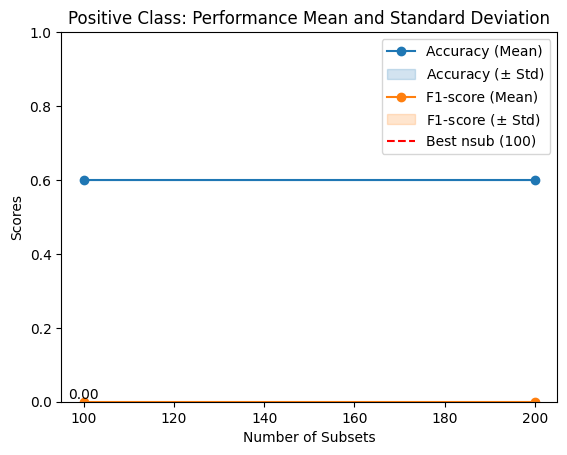

In [11]:
plot_nsub_step_2(ncell_test_acc, ncell_test_f1, n_cells_x_axis)

In [12]:
def plot_nsub_step_2(acc_5_means, f1_5_means, n_sub_step2_x_axis):
    
    
    acc_ncells_5_means = [np.mean(acc) for acc in acc_5_means]
    print(acc_ncells_5_means)
    f1_ncells_5_means = [np.mean(f1) for f1 in f1_5_means]
    print(f1_ncells_5_means)
    
    acc_ncells_5_stds = [np.std(acc) for acc in acc_5_means]

    f1_ncells_5_stds = [np.std(f1) for f1 in f1_5_means]
    
    max_idx = f1_ncells_5_means.index(np.max(f1_ncells_5_means))
    # Plot Accuracy Mean
    plt.plot(n_sub_step2_x_axis, acc_ncells_5_means, marker='o', label='Accuracy (Mean)', color='C0')
    # Plot Accuracy Std as a shaded region
    acc_upper = np.array(acc_ncells_5_means) + np.array(acc_ncells_5_stds)
    acc_lower = np.array(acc_ncells_5_means) - np.array(acc_ncells_5_stds)
    plt.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')
    
    # Plot F1-score Mean
    plt.plot(n_sub_step2_x_axis, f1_ncells_5_means, marker='o', label='F1-score (Mean)', color='C1')
    # Plot F1-score Std as a shaded region
    f1_upper = np.array(f1_ncells_5_means) + np.array(f1_ncells_5_stds)
    f1_lower = np.array(f1_ncells_5_means) - np.array(f1_ncells_5_stds)
    plt.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')

    y = f1_ncells_5_means[max_idx]
    plt.text(n_sub_step2_x_axis[max_idx], y, f"{y:.2f}", ha='center', va='bottom')
    
    plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
    plt.ylim(0,1)
    plt.title('Positive Class: Performance Mean and Standard Deviation')
    plt.xlabel("Number of Subsets")
    plt.ylabel("Scores")
    plt.legend()
    plt.show()